# STFateFlow on ARTISTA Regeneration

In [1]:
# Optional: run once if dependencies are missing in current kernel.
# You can uncomment the pip lines if needed.
# %pip install anndata scanpy torch torch-geometric torchcfm torchdyn tqdm matplotlib
from __future__ import annotations

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import importlib
import math
import sys
from pathlib import Path

repo_root = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

required = [
    'anndata',
    'numpy',
    'torch',
    'matplotlib',
    'torch_geometric',
    'torchcfm',
    'torchdyn',
    # 'nicheflow',
]

missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
    except Exception:
        missing.append(pkg)


SEED = 2026
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.set_float32_matmul_precision('high')

if not torch.cuda.is_available():
    raise RuntimeError('未检测到 CUDA GPU。请切换到可用 GPU 的环境后再训练。')

device = torch.device('cuda')
print('device =', device)
print('cuda name =', torch.cuda.get_device_name(0))


device = cuda
cuda name = NVIDIA A800 80GB PCIe


In [2]:
# -----------------------------
# User configurable parameters
# -----------------------------
h5ad_fp = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ARTISTA/Regeneration_affine_preprocessed_ae.h5ad')
work_dir = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/artista_regeneration')
work_dir.mkdir(parents=True, exist_ok=True)
flow_ckpt_fp = work_dir / 'artista_regeneration_ae.pt'

coord_obsm_key = 'X_spatial_input'

print('h5ad path:', h5ad_fp)
print('output dir:', work_dir)


h5ad path: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ARTISTA/Regeneration_affine_preprocessed_ae.h5ad
output dir: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/artista_regeneration


In [6]:
def _as_float_or_none(v):
    try:
        return float(v)
    except Exception:
        return None


def canonical_time_order(values):
    vals = list(values)
    as_float = [_as_float_or_none(v) for v in vals]
    if all(v is not None for v in as_float):
        return [x for _, x in sorted(zip(as_float, vals), key=lambda z: z[0])]
    return sorted(vals, key=lambda x: str(x))


def find_time_key(keys, query):
    query_f = _as_float_or_none(query)
    if query in keys:
        return query
    for k in keys:
        kf = _as_float_or_none(k)
        if query_f is not None and kf is not None and abs(kf - query_f) < 1e-9:
            return k
    q = str(query)
    for k in keys:
        if str(k) == q:
            return k
    raise KeyError(f'Timepoint {query} not found in {keys}')


def nn_of_x_in_y(x: torch.Tensor, y: torch.Tensor, chunk_size: int = 5000):
    idxs = []
    dists = []

    n_chunks = math.ceil(x.size(0) / chunk_size)
    for i in range(n_chunks):
        start = i * chunk_size
        end = (i + 1) * chunk_size
        d = torch.cdist(x[start:end], y)
        min_dist, min_idx = torch.min(d, dim=-1)
        idxs.append(min_idx)
        dists.append(min_dist)

    return torch.cat(idxs), torch.cat(dists)

from typing import Optional
from functools import partial
import ot as pot

def wasserstein_distance(
    x0: torch.Tensor,
    x1: torch.Tensor,
    method: Optional[str] = None,
    reg: float = 0.05,
    power: int = 1,
    **kwargs,
) -> float:
    assert power == 1 or power == 2
    if method == "exact" or method is None:
        ot_fn = pot.emd2
    elif method == "sinkhorn":
        ot_fn = partial(pot.sinkhorn2, reg=reg)
    else:
        raise ValueError(f"Unknown method: {method}")

    a, b = pot.unif(x0.shape[0]), pot.unif(x1.shape[0])
    if x0.dim() > 2:
        x0 = x0.reshape(x0.shape[0], -1)
    if x1.dim() > 2:
        x1 = x1.reshape(x1.shape[0], -1)
    M = torch.cdist(x0, x1)
    if power == 2:
        M = M**2
    ret = ot_fn(a, b, M.detach().cpu().numpy(), numItermax=1e7)
    if power == 2:
        ret = math.sqrt(ret)
    return ret


In [5]:
adata = ad.read_h5ad(h5ad_fp)
print('adata shape:', adata.shape)
print('obsm keys:', list(adata.obsm.keys()))

import scanpy as sc

sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True, batch_key='Batch')

# Map user-provided spatial coordinates to the expected key.
# Gene features are read directly from adata.X by InfiniteGlobalRPCDataset.
adata.obsm['spatial'] = np.asarray(adata.obsm[coord_obsm_key], dtype=np.float32)

timepoint_col = 'time'
cell_type_col = 'Annotation'

if str(adata.obs[cell_type_col].dtype) != 'category':
    adata.obs[cell_type_col] = adata.obs[cell_type_col].astype('category')

timepoints_ordered = canonical_time_order(adata.obs[timepoint_col].dropna().unique())

print('timepoint column:', timepoint_col)
print('cell type column:', cell_type_col)
print('ordered timepoints:', timepoints_ordered)

import torch

using_potential = True

if using_potential:
    torch.backends.cuda.enable_flash_sdp(False)
    torch.backends.cuda.enable_mem_efficient_sdp(False)
    torch.backends.cuda.enable_math_sdp(True)


/data/yuz/envs/nicheflow/lib/python3.11/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


adata shape: (46189, 16379)
obsm keys: ['X_ae', 'X_gene_input', 'X_pca', 'X_spatial', 'X_spatial_input', 'spatial']
timepoint column: time
cell type column: Annotation
ordered timepoints: [np.float64(2.0), np.float64(5.0), np.float64(10.0), np.float64(15.0), np.float64(20.0)]


/data/yuz/envs/nicheflow/lib/python3.11/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## Interpolation-CFM (real t0 source + velocity field supervision)

This section trains a new model with:
1. source state from real t0 data,
2. input as interpolation state between t0 and t1,
3. target as instantaneous velocity field from the interpolation path derivative.

In [ ]:
import importlib
import core.datasets.model_dataset as ds_mod
import core.models.backbones.pc_transformer as pc_mod
import core.models.STFateFlow as flow_mod

pc_mod = importlib.reload(pc_mod)

stfateflowdataset = ds_mod.STFateFlowDataset
stfateflow_collate = ds_mod.stfateflow_collate
PointCloudTransformer = pc_mod.PointCloudTransformer
stfateflow_model = flow_mod.STFateFlow_Module

test_timepoint = -1.0

flow_ckpt_fp = work_dir / 'artista_ae.pt'
size_per_slice = 2048
train_steps = 2000
train_num_workers = 4
batch_size = 2
num_steps_ode = 20
# Mixed precision on GPU: 'bf16' or 'fp16'
amp_dtype = 'bf16'

# Suggestion #1: default to soft-gating during inference.
dataset_name = 'artista'
fgw_alpha = 0.5
pi_cache_dir = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ot_pis')
pi_cache_path = pi_cache_dir / f'fgwot_pi_{dataset_name}_alpha{fgw_alpha}_ae_triu.npz'

dataset = stfateflowdataset(
    adata=adata,
    gene_key="X_ae",
    timepoint_column=timepoint_col,
    cell_type_column=cell_type_col,
    timepoints_ordered=timepoints_ordered,
    seed=SEED,
    size_per_slice=size_per_slice,
    ot_plan_cache_path= pi_cache_path,
    ot_plan_normalize=True,
    test_timepoint=test_timepoint,
)

train_loader = DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    num_workers=train_num_workers,
    pin_memory=True,
    persistent_workers=(train_num_workers > 0),
    collate_fn=stfateflow_collate,
)

device = torch.device("cuda:1")

n_genes = adata.obsm["X_ae"].shape[1]
n_slices = len(timepoints_ordered)

backbone = PointCloudTransformer(
    gene_dim=n_genes,
    coord_dim=2,
    using_potential=True,
    gradient_checkpointing=True
)

stfateflow = stfateflow_model(
    lambda_features=0.1,
    lambda_pos=1.0,
    backbone=backbone,
    num_steps=num_steps_ode,
    use_potential=True,
    potential_mode="split"
).to(device)

# Training hyperparameters
lr = 3e-4
weight_decay = 1e-5
max_grad_norm = 1.0
optimizer = torch.optim.AdamW(stfateflow.parameters(), lr=lr, weight_decay=weight_decay)

autocast_dtype = torch.bfloat16 if amp_dtype == 'bf16' else torch.float16
use_scaler = amp_dtype == 'fp16'
scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)
print('lr =', lr, 'max_grad_norm =', max_grad_norm, 'amp_dtype =', amp_dtype, 'use_scaler =', use_scaler)


In [ ]:
stfateflow.train()
stfateflow_iter = iter(train_loader)
stfateflow_loss_hist = []
stfateflow_diag_hist = []

stfateflow_pbar = tqdm(range(train_steps), desc='Training STFateFlow (balanced)')
for step in stfateflow_pbar:

    batch = next(stfateflow_iter)
    batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

    optimizer.zero_grad(set_to_none=True)
    with torch.autocast(device_type='cuda', dtype=autocast_dtype, enabled=True):
        losses = stfateflow.loss(batch)
        loss = losses['loss']

    if use_scaler:
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(stfateflow.parameters(), max_grad_norm)
        scaler.step(optimizer)
        scaler.update()
    else:
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(stfateflow.parameters(), max_grad_norm)
        optimizer.step()

    stfateflow_loss_hist.append(float(loss.detach().cpu()))
    stfateflow_diag_hist.append(
        {
            'loss': float(loss.detach().cpu()),
            'loss_x': float(losses['loss_x'].detach().cpu()),
            'loss_pos': float(losses['loss_pos'].detach().cpu()),
            'grad_norm': float(torch.as_tensor(grad_norm).detach().cpu()),
            'delta_t': float(batch['delta_t'].mean().detach().cpu()),
            't0_raw': tuple(float(v) for v in batch['t0_raw'].detach().cpu().tolist()),
            't1_raw': tuple(float(v) for v in batch['t1_raw'].detach().cpu().tolist()),
        }
    )

torch.save(
    {
        'flow_state_dict': stfateflow.state_dict(),
        'n_genes': n_genes,
        'n_slices': n_slices,
        'timepoints_ordered': timepoints_ordered,
        'config': {
            'model': 'STFateFlow_khead_balanced',
            'size_per_slice': size_per_slice,
            'train_steps': train_steps,
            'lr': lr,
            'weight_decay': weight_decay,
            'max_grad_norm': max_grad_norm,
            'amp_dtype': amp_dtype,
            'num_steps_ode': num_steps_ode,
            'lambda_features': 0.1,
            'lambda_pos': 1.0,
            'lambda_cdm': 1.0,
        },
    },
    flow_ckpt_fp,
)
print('Saved STFateFlow checkpoint:', flow_ckpt_fp)

loss_arr = np.asarray(stfateflow_loss_hist, dtype=np.float64)
window = min(100, max(1, len(loss_arr)))
ma = np.convolve(loss_arr, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_arr, alpha=0.35, label='raw')
axes[0].plot(np.arange(window - 1, window - 1 + len(ma)), ma, linewidth=2, label=f'ma{window}')
axes[0].set_title('STFateFlow training loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].legend(frameon=False)

diag_delta_t = np.asarray([d['delta_t'] for d in stfateflow_diag_hist], dtype=np.float64)
axes[1].scatter(diag_delta_t, loss_arr, s=8, alpha=0.35)
axes[1].set_title('Loss by transition interval')
axes[1].set_xlabel('delta_t')
axes[1].set_ylabel('Loss')
plt.tight_layout()
plt.show()


In [13]:
from core.models.checkpointing import load_stfateflow_checkpoint, release_training_memory

In [14]:
device = torch.device("cuda:1")
flow_ckpt_fp = work_dir / "artista_ae.pt"

stfateflow, load_info = load_stfateflow_checkpoint(
    flow_ckpt_fp,
    device=device,
    use_potential=True,          # 势能模型这里必须 True
    gradient_checkpointing=False # 推理不需要 checkpointing
)

print("Loaded:", load_info["path"])
print("missing:", load_info["missing_keys"])
print("unexpected:", load_info["unexpected_keys"])


Loaded: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/artista_regeneration/artista_ae.pt
missing: []
unexpected: []


In [ ]:
release_training_memory(
    "optimizer", "scaler", "loss", "losses", "batch",
    namespace=globals(),
)

stfateflow.eval()

In [ ]:
import importlib
from types import MethodType
import core.models.STFateFlow as flow_mod

flow_mod = importlib.reload(flow_mod)
stfateflow.predict_potential = MethodType(flow_mod.STFateFlow_Module.predict_potential, stfateflow)

device = torch.device("cuda:1")

potential_dict = {}
for source_timepoint in [2.0, 5.0, 10.0, 15.0, 20.0]:
    # source_timepoint = 10.0

    source_pc = dataset.timepoint_pc[find_time_key(timepoints_ordered, source_timepoint)]

    X_t0 = source_pc.x.unsqueeze(0).to(device)
    pos_t0 = source_pc.pos.unsqueeze(0).to(device)

    n_cells = X_t0.size(1)
    ohe_target = source_pc.ct_ohe.unsqueeze(0).to(device)
    sample_t_start = float(source_pc.t_value.item())
    sample_t_start = torch.as_tensor(sample_t_start, device=X_t0.device, dtype=X_t0.dtype)

    stfateflow.eval()

    potential = stfateflow.predict_potential(
        X_t=X_t0,          # shape [B, N, G]
        pos_t=pos_t0,      # shape [B, N, 2]
        t=sample_t_start,                # float 或 shape [B]
        chunk_size=2048,           # 还爆就改 64 / 32
        output_device="cpu",
    )

    potential_np = potential.squeeze(0).numpy()
    potential_dict[source_timepoint] = potential_np


In [17]:
import numpy as np
import pandas as pd

potential_key = "potential"

adata.obs[potential_key] = np.nan

for tp, potential in potential_dict.items():
    mask = adata.obs[timepoint_col].astype(str) == str(tp)
    idx = np.where(mask.to_numpy())[0]

    pot = np.asarray(potential).reshape(-1)

    if len(idx) != len(pot):
        raise ValueError(
            f"timepoint={tp}: cell count mismatch, "
            f"adata has {len(idx)} cells but potential has {len(pot)} values."
        )

    adata.obs.iloc[idx, adata.obs.columns.get_loc(potential_key)] = pot

adata.obsm[potential_key] = adata.obs[potential_key].to_numpy(dtype=np.float32)[:, None]

print(adata.obs[potential_key].describe())
print("missing potential:", int(adata.obs[potential_key].isna().sum()))

count    46189.000000
mean        -0.091643
std          0.324953
min         -0.831649
25%         -0.355998
50%         -0.099701
75%          0.167315
max          0.707735
Name: potential, dtype: float64
missing potential: 0


In [9]:
source_timepoint = 10.0
target_timepoint = 15.0
interpolation_timepoint = -1.0

t1_key = find_time_key(timepoints_ordered, source_timepoint)
t2_key = find_time_key(timepoints_ordered, target_timepoint)

source_pc = dataset.timepoint_pc[t1_key]
target_pc = dataset.timepoint_pc[t2_key]

X_t0 = source_pc.x.unsqueeze(0).to(device)
pos_t0 = source_pc.pos.unsqueeze(0).to(device)

n_cells = X_t0.size(1)
ohe_target = source_pc.ct_ohe.unsqueeze(0).to(device)
sample_t_start = float(source_pc.t_value.item())
sample_t_end = float(target_pc.t_value.item()) if interpolation_timepoint < 0 else float(interpolation_timepoint) - dataset.time_origin
print('sample_t_start =', sample_t_start, 'sample_t_end =', sample_t_end)

sample_t_start = 8.0 sample_t_end = 13.0


In [ ]:
stfateflow.eval()
with torch.no_grad():
    sample_out = stfateflow.sample(
        X_t0=X_t0,
        pos_t0=pos_t0,
        t_start=sample_t_start,
        t_end=sample_t_end,
        keep_trajectory=True,
        trajectory_device="cpu",
        inference_chunk_size=2048
    )

    # Compatible with both return styles:
    # 1) tuple/list: (x_traj, pos_traj)
    # 2) dict: {'x_traj': ..., 'pos_traj': ...}
    if isinstance(sample_out, dict):
        x_traj = sample_out.get('x_traj', None)
        pos_traj = sample_out.get('pos_traj', None)
        potential_traj = sample_out.get('potential_traj', None)

    last_x = x_traj[-1] if isinstance(x_traj, (list, tuple)) else x_traj
    last_pos = pos_traj[-1] if isinstance(pos_traj, (list, tuple)) else pos_traj

    pred_x_interp = last_x.reshape(-1, n_genes).detach().cpu().numpy()
    coord_dim = int(pos_t0.shape[-1])
    pred_pos_interp = last_pos.reshape(-1, coord_dim).detach().cpu().numpy()

# Source potential/velocity visualization is in the next cell.


In [ ]:
t2_key = interpolation_timepoint if interpolation_timepoint >= 0 else t2_key

gt_x_interp = dataset.timepoint_pc[t2_key].x.detach().cpu().numpy()
gt_pos_interp = dataset.timepoint_pc[t2_key].pos.detach().cpu().numpy()

idx_pred_to_gt_interp_t, dist_pred_to_gt_interp_t = nn_of_x_in_y(
    torch.tensor(pred_pos_interp, dtype=torch.float32),
    torch.tensor(gt_pos_interp, dtype=torch.float32),
)
idx_pred_to_gt_interp = idx_pred_to_gt_interp_t.detach().cpu().numpy()
dist_pred_to_gt_interp = dist_pred_to_gt_interp_t.detach().cpu().numpy()

matched_gt_x_interp = gt_x_interp[idx_pred_to_gt_interp]

import core.models.losses as losses_mod
chunked_chamfer_distance = importlib.reload(losses_mod).chunked_chamfer_distance
from matplotlib.lines import Line2D

chamfer_interp = float(
    chunked_chamfer_distance(
        torch.tensor(gt_pos_interp, dtype=torch.float32).unsqueeze(0),
        torch.tensor(pred_pos_interp, dtype=torch.float32).unsqueeze(0),
    ).detach().cpu()
)

pos_interp_wass = float(
    wasserstein_distance(
        torch.tensor(gt_pos_interp, dtype=torch.float32),
        torch.tensor(pred_pos_interp, dtype=torch.float32),
        power=1,
    )
)

# 读取 target 时间点的 annotation，并用于 GT / Pred 着色（Pred 使用匹配到的 GT 注释）
if 'Annotation' not in adata.obs.columns:
    raise KeyError("Missing adata.obs['Annotation']; please check annotation column name.")

target_global_indices = np.asarray(np.where(adata.obs[timepoint_col] == t2_key)[0])
gt_annotation_interp = adata.obs.iloc[target_global_indices]['Annotation'].astype(str).to_numpy()
if gt_annotation_interp.shape[0] != gt_pos_interp.shape[0]:
    n_min = min(gt_annotation_interp.shape[0], gt_pos_interp.shape[0])
    print(
        f"Warning: annotation count ({gt_annotation_interp.shape[0]}) != target cell count ({gt_pos_interp.shape[0]}), truncating to {n_min}."
    )
    gt_annotation_interp = gt_annotation_interp[:n_min]
    gt_pos_interp = gt_pos_interp[:n_min]
    gt_x_interp = gt_x_interp[:n_min]
    idx_pred_to_gt_interp_t, dist_pred_to_gt_interp_t = nn_of_x_in_y(
        torch.tensor(pred_pos_interp, dtype=torch.float32),
        torch.tensor(gt_pos_interp, dtype=torch.float32),
    )
    idx_pred_to_gt_interp = idx_pred_to_gt_interp_t.detach().cpu().numpy()
    matched_gt_x_interp = gt_x_interp[idx_pred_to_gt_interp]

pred_annotation_interp = gt_annotation_interp[idx_pred_to_gt_interp]
ann_levels = np.unique(np.concatenate([gt_annotation_interp, pred_annotation_interp]))
ann_to_idx = {ann: i for i, ann in enumerate(ann_levels)}
gt_color_idx = np.asarray([ann_to_idx[a] for a in gt_annotation_interp], dtype=int)
pred_color_idx = np.asarray([ann_to_idx[a] for a in pred_annotation_interp], dtype=int)

n_ann = len(ann_levels)
if n_ann <= 20:
    ann_cmap = plt.get_cmap('tab20', max(n_ann, 1))
else:
    ann_cmap = plt.get_cmap('gist_ncar', n_ann)

print(f'{source_timepoint} {target_timepoint} Chamfer distance: {chamfer_interp:.4f}')
print(f'{source_timepoint} {target_timepoint} coord Wasserstein distance: {pos_interp_wass:.4f}')
print(f'annotation categories: {n_ann}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(
    gt_pos_interp[:, 0],
    gt_pos_interp[:, 1],
    s=4,
    alpha=0.85,
    c=gt_color_idx,
    cmap=ann_cmap,
    vmin=0,
    vmax=max(n_ann - 1, 1),
)
axes[0].set_title(f'STFateFlow GT coords at t={target_timepoint} (annotation)')
axes[0].set_aspect('equal', adjustable='box')

axes[1].scatter(
    pred_pos_interp[:, 0],
    pred_pos_interp[:, 1],
    s=4,
    alpha=0.85,
    c=pred_color_idx,
    cmap=ann_cmap,
    vmin=0,
    vmax=max(n_ann - 1, 1),
)
mode_text = 'trajectory'
axes[1].set_title(f'Pred coords at t={target_timepoint} from t={source_timepoint}')
axes[1].set_aspect('equal', adjustable='box')

for ax in axes:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

legend_limit = 18
shown = ann_levels[:legend_limit]
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', markersize=6, markerfacecolor=ann_cmap(ann_to_idx[a]), markeredgecolor='none', label=a)
    for a in shown
]
if n_ann > legend_limit:
    legend_handles.append(Line2D([0], [0], linestyle='', label=f'... +{n_ann - legend_limit} more'))

legend_ncol = 2 if len(shown) > 10 else 1
axes[1].legend(
    handles=legend_handles,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=False,
    title='annotation',
    fontsize=8,
    title_fontsize=9,
    ncol=legend_ncol,
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

# Feature correlation from sample-averaged latent values.
# Each point in the first panel is one feature dimension.
def _safe_corrcoef(x, y):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan
    x = x[mask]
    y = y[mask]
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

pred_feature_mean = pred_x_interp.mean(axis=0)
gt_feature_mean = matched_gt_x_interp.mean(axis=0)
feature_mean_corr = _safe_corrcoef(pred_feature_mean, gt_feature_mean)

feature_min = float(np.nanmin([pred_feature_mean.min(), gt_feature_mean.min()]))
feature_max = float(np.nanmax([pred_feature_mean.max(), gt_feature_mean.max()]))
feature_pad = 0.05 * max(feature_max - feature_min, 1e-8)
feature_lim = [feature_min - feature_pad, feature_max + feature_pad]

# Cell-type averaged feature correlation.
# Each point in the second panel is one (cell type, feature dimension) pair.
ct_pred_means = []
ct_gt_means = []
ct_labels = []
ct_levels = np.unique(pred_annotation_interp)
for ct in ct_levels:
    ct_mask = pred_annotation_interp == ct
    if not np.any(ct_mask):
        continue
    ct_pred_mean = pred_x_interp[ct_mask].mean(axis=0)
    ct_gt_mean = matched_gt_x_interp[ct_mask].mean(axis=0)
    ct_pred_means.append(ct_pred_mean)
    ct_gt_means.append(ct_gt_mean)
    ct_labels.extend([ct] * ct_pred_mean.shape[0])

if len(ct_pred_means) == 0:
    raise RuntimeError('No cell-type groups available for feature mean correlation plot.')

ct_pred_feature_mean = np.concatenate(ct_pred_means)
ct_gt_feature_mean = np.concatenate(ct_gt_means)
ct_labels = np.asarray(ct_labels)
ct_feature_mean_corr = _safe_corrcoef(ct_pred_feature_mean, ct_gt_feature_mean)

ct_feature_min = float(np.nanmin([ct_pred_feature_mean.min(), ct_gt_feature_mean.min()]))
ct_feature_max = float(np.nanmax([ct_pred_feature_mean.max(), ct_gt_feature_mean.max()]))
ct_feature_pad = 0.05 * max(ct_feature_max - ct_feature_min, 1e-8)
ct_feature_lim = [ct_feature_min - ct_feature_pad, ct_feature_max + ct_feature_pad]

ct_to_idx = {ct: i for i, ct in enumerate(ct_levels)}
ct_color_idx = np.asarray([ct_to_idx[ct] for ct in ct_labels], dtype=int)
ct_cmap = plt.get_cmap('tab20', max(len(ct_levels), 1)) if len(ct_levels) <= 20 else plt.get_cmap('gist_ncar', len(ct_levels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(pred_feature_mean, gt_feature_mean, s=28, alpha=0.8, edgecolor='none')
axes[0].plot(feature_lim, feature_lim, 'r--', linewidth=1)
axes[0].set_xlim(feature_lim)
axes[0].set_ylim(feature_lim)
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_xlabel('Predicted mean feature value')
axes[0].set_ylabel('Matched GT mean feature value')
axes[0].set_title(f'Feature mean correlation | r={feature_mean_corr:.3f}')
axes[0].text(
    0.03,
    0.97,
    f'n_features={pred_feature_mean.shape[0]}',
    transform=axes[0].transAxes,
    va='top',
    ha='left',
)

axes[1].scatter(
    ct_pred_feature_mean,
    ct_gt_feature_mean,
    c=ct_color_idx,
    cmap=ct_cmap,
    vmin=0,
    vmax=max(len(ct_levels) - 1, 1),
    s=16,
    alpha=0.65,
    edgecolor='none',
)
axes[1].plot(ct_feature_lim, ct_feature_lim, 'r--', linewidth=1)
axes[1].set_xlim(ct_feature_lim)
axes[1].set_ylim(ct_feature_lim)
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_xlabel('Predicted cell-type mean feature value')
axes[1].set_ylabel('Matched GT cell-type mean feature value')
axes[1].set_title(f'Cell-type feature mean correlation | r={ct_feature_mean_corr:.3f}')
axes[1].text(
    0.03,
    0.97,
    f'n_annotations={len(ct_levels)}, n_points={ct_pred_feature_mean.shape[0]}',
    transform=axes[1].transAxes,
    va='top',
    ha='left',
)

ct_legend_limit = 18
ct_shown = ct_levels[:ct_legend_limit]
ct_color_den = max(len(ct_levels) - 1, 1)
ct_handles = [
    Line2D(
        [0],
        [0],
        marker='o',
        linestyle='',
        markersize=6,
        markerfacecolor=ct_cmap(ct_to_idx[ct] / ct_color_den),
        markeredgecolor='none',
        label=ct,
    )
    for ct in ct_shown
]

if len(ct_levels) > ct_legend_limit:
    ct_handles.append(Line2D([0], [0], linestyle='', label=f'... +{len(ct_levels) - ct_legend_limit} more'))
axes[1].legend(
    handles=ct_handles,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=False,
    title='annotation',
    fontsize=8,
    title_fontsize=9,
)

plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()

print(f'Feature mean correlation r = {feature_mean_corr:.4f}')
print(f'Cell-type feature mean correlation r = {ct_feature_mean_corr:.4f}')


In [12]:
source_potential_step = 0
source_pos_step = 0
next_pos_step = 1

def _traj_step_to_numpy(step_value):
    if isinstance(step_value, torch.Tensor):
        arr = step_value.detach().cpu().numpy()
    else:
        arr = np.asarray(step_value)
    if arr.ndim >= 3 and arr.shape[0] == 1:
        arr = arr[0]
    return np.asarray(arr)

source_potential = _traj_step_to_numpy(potential_traj[source_potential_step]).reshape(-1)
source_pos_np = _traj_step_to_numpy(pos_traj[source_pos_step])
next_pos_np = _traj_step_to_numpy(pos_traj[next_pos_step])

source_pc_pos_np = source_pc.pos.detach().cpu().numpy()
if source_pc_pos_np.shape == source_pos_np.shape:
    source_alignment_maxerr = float(np.max(np.abs(source_pc_pos_np - source_pos_np)))
    if source_alignment_maxerr > 1e-4:
        raise RuntimeError(
            f'pos_traj[0] is not aligned to source_pc.pos; max abs error={source_alignment_maxerr:.6g}'
        )
else:
    source_alignment_maxerr = float('nan')
    print(f'Warning: source_pc.pos shape {source_pc_pos_np.shape} differs from pos_traj[0] {source_pos_np.shape}.')

source_dt = 1.0 / max(int(getattr(stfateflow, 'num_steps', len(pos_traj) - 1)), 1)
source_vpos_np = (next_pos_np - source_pos_np) / source_dt
source_speed = np.linalg.norm(source_vpos_np[:, :2], axis=1)

source_potential_adata = adata[adata.obs['time'] == source_timepoint].copy()

source_potential_adata.obsm['potential'] = source_potential.astype(np.float32)[:, None]
source_potential_adata.obsm['velocity_source'] = source_vpos_np.astype(np.float32)


IndexError: list index out of range

In [27]:
adata_p = adata[adata.obs["inj_uninj"] == "inj"]
adata_p = adata_p[adata_p.obs["D_V"] == "D"]

/data/yuz/tmp/ipykernel_2430878/3826672521.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pot.obs["potential"] = potential
/data/yuz/envs/nicheflow/lib/python3.11/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/data/yuz/tmp/ipykernel_2430878/3826672521.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = plot_df.groupby(cell_type_key)["potential"].median().sort_values().index


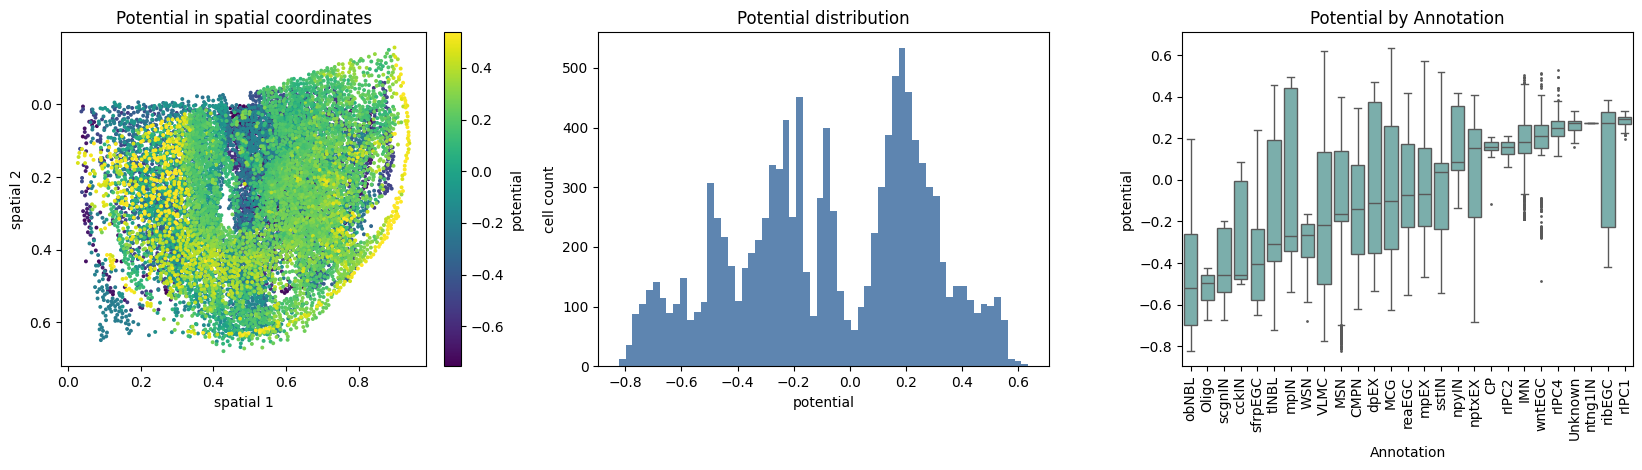

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


adata_pot = adata_p

potential = np.asarray(adata_pot.obsm["potential"]).reshape(-1)

adata_pot.obs["potential"] = potential

# 自动找到空间坐标
spatial = np.asarray(adata_pot.obsm["X_spatial_input"])

# 可选：按 1%-99% 截断颜色，避免极端值压扁色彩
vmin, vmax = np.nanpercentile(potential, [1, 99])

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

sc0 = axes[0].scatter(
    spatial[:, 0],
    -spatial[:, 1],
    c=potential,
    s=8,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    linewidths=0,
)
axes[0].set_title("Potential in spatial coordinates")
axes[0].set_aspect("equal", adjustable="box")
axes[0].invert_yaxis()
axes[0].set_xlabel("spatial 1")
axes[0].set_ylabel("spatial 2")
plt.colorbar(sc0, ax=axes[0], fraction=0.046, pad=0.04, label="potential")

axes[1].hist(potential[np.isfinite(potential)], bins=60, color="#4c78a8", alpha=0.9)
axes[1].set_title("Potential distribution")
axes[1].set_xlabel("potential")
axes[1].set_ylabel("cell count")

cell_type_key = "Annotation" if "Annotation" in adata_pot.obs else None
if cell_type_key is None:
    cell_type_candidates = [
        c for c in adata_pot.obs.columns
        if "type" in c.lower() or "annotation" in c.lower() or "cell" in c.lower()
    ]
    cell_type_key = cell_type_candidates[0] if cell_type_candidates else None

if cell_type_key is not None:
    plot_df = adata_pot.obs[[cell_type_key, "potential"]].copy()
    order = plot_df.groupby(cell_type_key)["potential"].median().sort_values().index
    sns.boxplot(
        data=plot_df,
        x=cell_type_key,
        y="potential",
        order=order,
        ax=axes[2],
        color="#72b7b2",
        fliersize=1,
    )
    axes[2].set_title(f"Potential by {cell_type_key}")
    axes[2].tick_params(axis="x", rotation=90)
else:
    axes[2].axis("off")
    axes[2].text(0.5, 0.5, "No cell type column found", ha="center", va="center")

plt.tight_layout()
plt.show()

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer

def regress_genes(
    adata, potential_key="potential", regression_model=None, key_added="regression"
) -> None:

    # We want to regress gene expression from the potential
    x_train = np.array(adata.obsm[potential_key]).reshape(-1, 1).astype(np.float64)

    # The model is a spline regression
    if not regression_model:
        regression_model = make_pipeline(
            SplineTransformer(knots="quantile", extrapolation="continue"),
            LinearRegression(),
        )

    adata.layers[key_added] = adata.X.copy()

    # Fit the regression_model for each gene and keep the score and argmax
    for i, gene in tqdm(enumerate(adata.var_names)):

        # The target gene expression
        y_train = adata[:, gene].X.toarray().ravel()

        # Fit the regression_model
        regression_model.fit(x_train, y_train)

        # Store the results
        adata.layers[key_added][:, i] = regression_model.predict(x_train)
        adata.var.loc[gene, key_added + "_score"] = regression_model.score(
            x_train, y_train
        )
        adata.var.loc[gene, key_added + "_argmax"] = regression_model.predict(
            np.sort(x_train, axis=0)
        ).argmax()


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_single_gene_trend(
    adata,
    gene,
    potential_key="potential",
    annotation_key="annotation",
    regression_key="regression",
    show_regression=False,
    **kwargs,
):

    sns.scatterplot(
        x=adata.obsm[potential_key].ravel(),
        y=adata[:, gene].X.toarray().ravel(),
        hue=adata.obs[annotation_key],
        **kwargs,
    )

    if show_regression:
        xx = adata.obsm[potential_key]
        yy = adata[:, gene].layers[regression_key].ravel()
        sns.lineplot(x=xx, y=yy)

    sns.despine()

    plt.title(gene)
    plt.xlabel("potential")
    plt.ylabel("gene expression")
    plt.legend(markerscale=3)
    plt.show()


In [31]:
adata_filter = adata[adata.obs["Annotation"].isin(["reaEGC", "rIPC1", "IMN", "nptxEX"])].copy()


/data/yuz/envs/nicheflow/lib/python3.11/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [32]:
# pip install magic-impute
import magic

magic_operator = magic.MAGIC()
magic_operator.fit(adata_filter.obsm["X_ae"])
diff_op_t = np.linalg.matrix_power(magic_operator.diff_op.toarray(), 3)
adata_filter.X = diff_op_t @ np.log1p(adata_filter.layers["counts"].toarray())


Running MAGIC on 5047 cells and 10 genes.
Calculating graph and diffusion operator...
  Calculating KNN search...
  Calculated KNN search in 0.14 seconds.
  Calculating affinities...
  Calculated affinities in 0.87 seconds.
Calculated graph and diffusion operator in 1.08 seconds.


In [33]:
regress_genes(adata_filter, potential_key='potential', key_added='regression')


0it [00:00, ?it/s]

ValueError: Per-column arrays must each be 1-dimensional

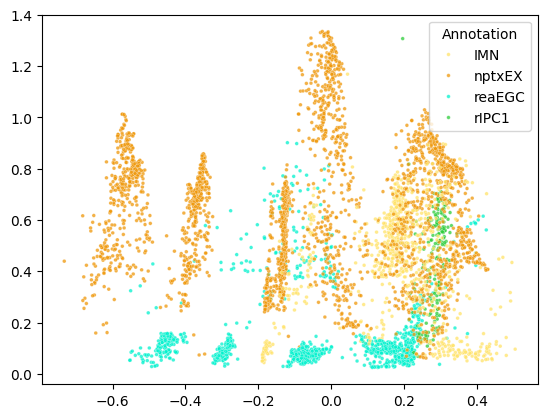

In [34]:
palette = {
    "IMN": "#FFE368",
    "dpEX": "#FF6666",
    "mpEX": "#d33f6a",
    "nptxEX": "#ef9708",
    "rIPC1": "#2CCD39",
    "rIPC2": "#7E0AD1",
    "reaEGC": "#00F2CE",
    "wntEGC": "#1ce6ff",
}

plot_single_gene_trend(
    adata_filter,
    "NPTX1 | AMEX60DD031350",
    s=7,
    palette=palette,
    alpha=0.75,
    show_regression=True,
    annotation_key="Annotation",
)


pos 0.02 x 0.46


stVCR pos 0.04 x 0.39
